# Импорты

In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


# Подготовка датасета

In [32]:
# 1. Загрузка данных
# Используем continuous dataset.csv, так как там есть все переменные
df = pd.read_csv('Electricity Load Forecasting/continuous dataset.csv', index_col=0, parse_dates=True)
df.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [33]:
df.describe()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
count,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000
mean,1182.868647,27.399111,0.018313,0.079979,13.391049,26.921023,0.017844,0.106265,7.046675,24.719513,0.016867,0.144681,3.567589,0.704795,0.062937,0.727793
std,192.068896,1.675462,0.001607,0.065589,7.295502,3.018129,0.001889,0.086293,4.103711,2.414019,0.001584,0.087899,1.710522,3.147470,0.242852,0.445100
min,85.192500,22.953455,0.012054,0.000000,0.008979,19.765222,0.010247,0.000009,0.060394,19.933740,0.009655,0.000032,0.015497,0.000000,0.000000,0.000000
25%,1020.056900,26.160455,0.017236,0.026451,7.544958,24.769281,0.016584,0.036819,3.955051,22.954652,0.015800,0.075775,2.298887,0.000000,0.000000,0.000000
50%,1168.427700,27.118051,0.018590,0.065201,12.182103,26.167352,0.018351,0.085968,5.992762,24.001718,0.017167,0.130188,3.413994,0.000000,0.000000,1.000000
75%,1327.563950,28.558344,0.019521,0.117310,18.661282,28.712335,0.019242,0.157288,9.409871,26.243402,0.018067,0.200012,4.670628,0.000000,0.000000,1.000000
max,1754.882000,35.039575,0.022690,0.521240,39.229726,39.063440,0.022165,0.484985,24.483937,34.216211,0.021066,0.477783,10.288902,22.000000,1.000000,1.000000


In [34]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 48048 entries, 2015-01-03 01:00:00 to 2020-06-27 00:00:00
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   nat_demand  48048 non-null  float64
 1   T2M_toc     48048 non-null  float64
 2   QV2M_toc    48048 non-null  float64
 3   TQL_toc     48048 non-null  float64
 4   W2M_toc     48048 non-null  float64
 5   T2M_san     48048 non-null  float64
 6   QV2M_san    48048 non-null  float64
 7   TQL_san     48048 non-null  float64
 8   W2M_san     48048 non-null  float64
 9   T2M_dav     48048 non-null  float64
 10  QV2M_dav    48048 non-null  float64
 11  TQL_dav     48048 non-null  float64
 12  W2M_dav     48048 non-null  float64
 13  Holiday_ID  48048 non-null  int64  
 14  holiday     48048 non-null  int64  
 15  school      48048 non-null  int64  
dtypes: float64(13), int64(3)
memory usage: 6.2 MB


In [35]:
# 2. Обработка пропусков (если есть)
df = df.ffill()

# 3. Масштабирование
# Для RNN лучше всего подходит MinMaxScaler в диапазон [0, 1]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# 4. Создание выборок со скользящим окном
def create_sequences(data, window_size, gap=72, target_idx=0):
    """
    window_size: сколько часов смотрим в прошлое
    gap: зазор (72 часа по условию задачи)
    target_idx: индекс колонки с нагрузкой (обычно первая)
    """
    X, y = [], []
    for i in range(len(data) - window_size - gap):
        # Окно признаков
        X.append(data[i:(i + window_size)])
        # Целевое значение через gap часов после конца окна
        y.append(data[i + window_size + gap, target_idx])
    return np.array(X), np.array(y)

# Параметры: возьмем неделю (168ч) как историю для прогноза
WINDOW_SIZE = 168 
GAP = 72

X, y = create_sequences(scaled_data, WINDOW_SIZE, GAP)

# 5. Разбиение на train/test
# Для временных рядов нельзя перемешивать данные (shuffle=False)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Формат данных [samples, time_steps, features]: {X_train.shape}")

Формат данных [samples, time_steps, features]: (38246, 168, 16)


# RNN

In [ ]:
# Преобразуем данные в тензоры
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

In [39]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # out: тензор с выходными данными всех шагов (batch, seq, hidden)
        # _ : скрытое состояние последнего шага
        out, _ = self.rnn(x)
        # Берем только последний временной шаг для прогноза
        out = self.fc(out[:, -1, :])
        return out

input_dim = X_train.shape[2] # Кол-во признаков
model = SimpleRNN(input_size=input_dim, hidden_size=64, output_size=1)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Epoch [1/20] | Loss (T/V): 0.00482 / 0.00701 | Acc (T/V): 39.94% / 29.79%
Epoch [2/20] | Loss (T/V): 0.00470 / 0.00711 | Acc (T/V): 40.87% / 35.05%
Epoch [3/20] | Loss (T/V): 0.00460 / 0.00703 | Acc (T/V): 41.46% / 34.06%
Epoch [4/20] | Loss (T/V): 0.00449 / 0.00719 | Acc (T/V): 42.35% / 34.41%
Epoch [5/20] | Loss (T/V): 0.00428 / 0.00825 | Acc (T/V): 43.88% / 30.88%
Epoch [6/20] | Loss (T/V): 0.00423 / 0.00818 | Acc (T/V): 44.07% / 31.13%
Epoch [7/20] | Loss (T/V): 0.00397 / 0.00759 | Acc (T/V): 46.23% / 37.74%
Epoch [8/20] | Loss (T/V): 0.00378 / 0.00745 | Acc (T/V): 47.15% / 34.82%
Epoch [9/20] | Loss (T/V): 0.00369 / 0.00737 | Acc (T/V): 47.32% / 35.31%
Epoch [10/20] | Loss (T/V): 0.00351 / 0.00839 | Acc (T/V): 48.48% / 33.07%
Epoch [11/20] | Loss (T/V): 0.00358 / 0.00675 | Acc (T/V): 48.14% / 35.85%
Epoch [12/20] | Loss (T/V): 0.00339 / 0.00731 | Acc (T/V): 49.48% / 37.11%
Epoch [13/20] | Loss (T/V): 0.00306 / 0.00758 | Acc (T/V): 52.26% / 33.54%
Epoch [14/20] | Loss (T/V): 0.0027

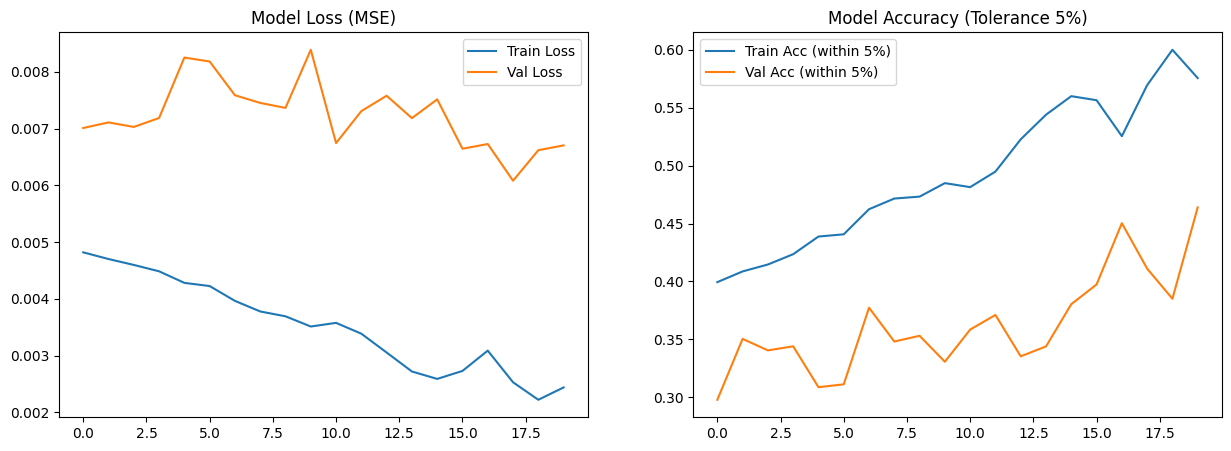

In [41]:
def calculate_accuracy(y_true, y_pred, tolerance=0.05):
    """Считает процент ответов с ошибкой менее 5%"""
    diff = torch.abs(y_true - y_pred) / (torch.abs(y_true) + 1e-9)
    acc = (diff < tolerance).float().mean()
    return acc

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    train_loss, train_acc = 0, 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_acc += calculate_accuracy(batch_y, outputs).item()
    
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            v_loss = criterion(outputs, batch_y)
            val_loss += v_loss.item()
            val_acc += calculate_accuracy(batch_y, outputs).item()
    
    # Сохраняем средние значения
    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(test_loader))
    history['train_acc'].append(train_acc / len(train_loader))
    history['val_acc'].append(val_acc / len(test_loader))
    
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Loss (T/V): {history['train_loss'][-1]:.5f} / {history['val_loss'][-1]:.5f} | "
          f"Acc (T/V): {history['train_acc'][-1]:.2%} / {history['val_acc'][-1]:.2%}")

# --- Визуализация ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График Loss
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Model Loss (MSE)')
ax1.legend()

# График Accuracy
ax2.plot(history['train_acc'], label='Train Acc (within 5%)')
ax2.plot(history['val_acc'], label='Val Acc (within 5%)')
ax2.set_title('Model Accuracy (Tolerance 5%)')
ax2.legend()

plt.show()

# LSTM

In [59]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Слой LSTM
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout)
        
        # Полносвязный слой для вывода
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # Инициализация начальных состояний h0 и c0
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # out: (batch, seq_len, hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        
        # Берем выход последнего временного шага
        out = self.fc(out[:, -1, :])
        return out

# Инициализация
input_dim = X_train.shape[2]
model_lstm = LSTMModel(input_size=input_dim, hidden_size=128, num_layers=2, output_size=1)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=0.001)

Epoch [1/20] | Loss (T/V): 0.01079 / 0.00680 | Acc (T/V): 31.07% / 31.53%
Epoch [2/20] | Loss (T/V): 0.00487 / 0.00810 | Acc (T/V): 39.67% / 20.09%
Epoch [3/20] | Loss (T/V): 0.00477 / 0.00654 | Acc (T/V): 40.20% / 36.20%
Epoch [4/20] | Loss (T/V): 0.00465 / 0.00784 | Acc (T/V): 41.22% / 25.22%
Epoch [5/20] | Loss (T/V): 0.00458 / 0.00689 | Acc (T/V): 41.73% / 32.09%
Epoch [6/20] | Loss (T/V): 0.00455 / 0.00681 | Acc (T/V): 42.19% / 35.41%
Epoch [7/20] | Loss (T/V): 0.00434 / 0.00793 | Acc (T/V): 43.51% / 30.79%
Epoch [8/20] | Loss (T/V): 0.00406 / 0.01065 | Acc (T/V): 45.70% / 37.31%
Epoch [9/20] | Loss (T/V): 0.00368 / 0.00727 | Acc (T/V): 48.63% / 35.96%
Epoch [10/20] | Loss (T/V): 0.00303 / 0.00729 | Acc (T/V): 52.43% / 40.03%
Epoch [11/20] | Loss (T/V): 0.00218 / 0.00596 | Acc (T/V): 59.94% / 39.05%
Epoch [12/20] | Loss (T/V): 0.00192 / 0.00629 | Acc (T/V): 63.44% / 46.45%
Epoch [13/20] | Loss (T/V): 0.00177 / 0.00664 | Acc (T/V): 65.24% / 37.08%
Epoch [14/20] | Loss (T/V): 0.0018

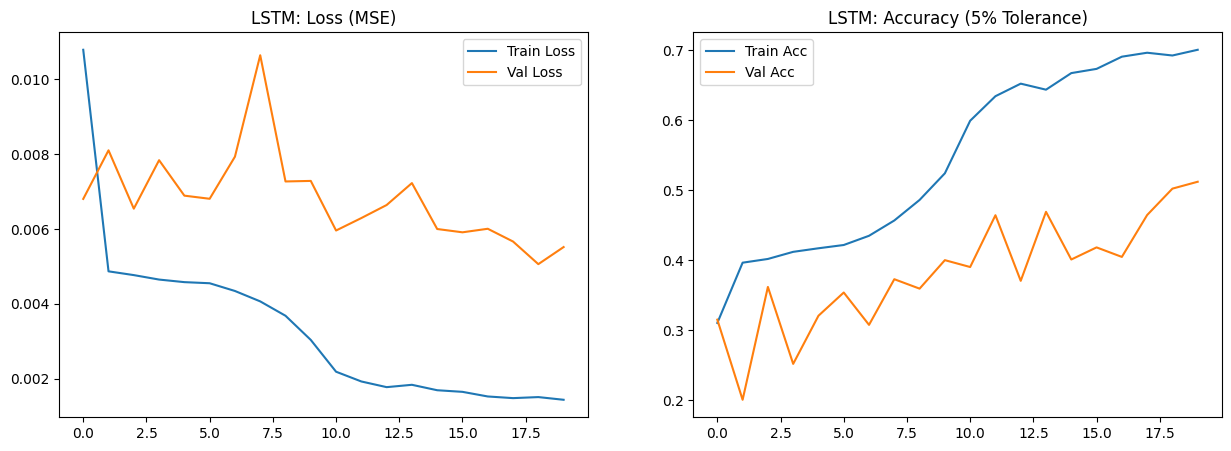

In [60]:
epochs = 20
lstm_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    model_lstm.train()
    train_loss, train_acc = 0, 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_lstm(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_acc += calculate_accuracy(batch_y, outputs).item()
    
    model_lstm.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model_lstm(batch_X)
            v_loss = criterion(outputs, batch_y)
            val_loss += v_loss.item()
            val_acc += calculate_accuracy(batch_y, outputs).item()
    
    lstm_history['train_loss'].append(train_loss / len(train_loader))
    lstm_history['val_loss'].append(val_loss / len(test_loader))
    lstm_history['train_acc'].append(train_acc / len(train_loader))
    lstm_history['val_acc'].append(val_acc / len(test_loader))
    
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Loss (T/V): {lstm_history['train_loss'][-1]:.5f} / {lstm_history['val_loss'][-1]:.5f} | "
          f"Acc (T/V): {lstm_history['train_acc'][-1]:.2%} / {lstm_history['val_acc'][-1]:.2%}")

# Отрисовка графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(lstm_history['train_loss'], label='Train Loss')
ax1.plot(lstm_history['val_loss'], label='Val Loss')
ax1.set_title('LSTM: Loss (MSE)')
ax1.legend()

ax2.plot(lstm_history['train_acc'], label='Train Acc')
ax2.plot(lstm_history['val_acc'], label='Val Acc')
ax2.set_title('LSTM: Accuracy (5% Tolerance)')
ax2.legend()
plt.show()

# GRU

In [71]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Слой GRU
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                          batch_first=True, dropout=dropout)
        
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # Начальное скрытое состояние (h0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Проход через GRU
        out, _ = self.gru(x, h0)
        
        # Берем выход последнего временного шага (last time step)
        out = self.fc(out[:, -1, :])
        return out

# Инициализация модели
input_dim = X_train.shape[2] 
model_gru = GRUModel(input_size=input_dim, hidden_size=64, num_layers=1, output_size=1)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_gru.parameters(), lr=0.001)

c:\Users\kitte\OneDrive\Рабочий стол\PY_LABS\ML PY\venv\Lib\site-packages\torch\nn\modules\rnn.py:1364: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch [1/20] | Loss (T/V): 0.01117 / 0.00760 | Acc (T/V): 26.23% / 28.93%
Epoch [2/20] | Loss (T/V): 0.00585 / 0.00639 | Acc (T/V): 32.85% / 34.47%
Epoch [3/20] | Loss (T/V): 0.00489 / 0.00700 | Acc (T/V): 39.71% / 29.55%
Epoch [4/20] | Loss (T/V): 0.00463 / 0.00703 | Acc (T/V): 41.12% / 34.51%
Epoch [5/20] | Loss (T/V): 0.00434 / 0.00869 | Acc (T/V): 43.11% / 22.72%
Epoch [6/20] | Loss (T/V): 0.00378 / 0.00582 | Acc (T/V): 46.66% / 40.36%
Epoch [7/20] | Loss (T/V): 0.00284 / 0.00384 | Acc (T/V): 52.88% / 44.97%
Epoch [8/20] | Loss (T/V): 0.00226 / 0.00456 | Acc (T/V): 58.12% / 37.06%
Epoch [9/20] | Loss (T/V): 0.00200 / 0.00403 | Acc (T/V): 61.17% / 48.91%
Epoch [10/20] | Loss (T/V): 0.00187 / 0.00388 | Acc (T/V): 62.55% / 48.02%
Epoch [11/20] | Loss (T/V): 0.00181 / 0.00380 | Acc (T/V): 63.56% / 46.49%
Epoch [12/20] | Loss (T/V): 0.00168 / 0.00414 | Acc (T/V): 65.16% / 48.69%
Epoch [13/20] | Loss (T/V): 0.00162 / 0.00390 | Acc (T/V): 66.25% / 50.79%
Epoch [14/20] | Loss (T/V): 0.0015

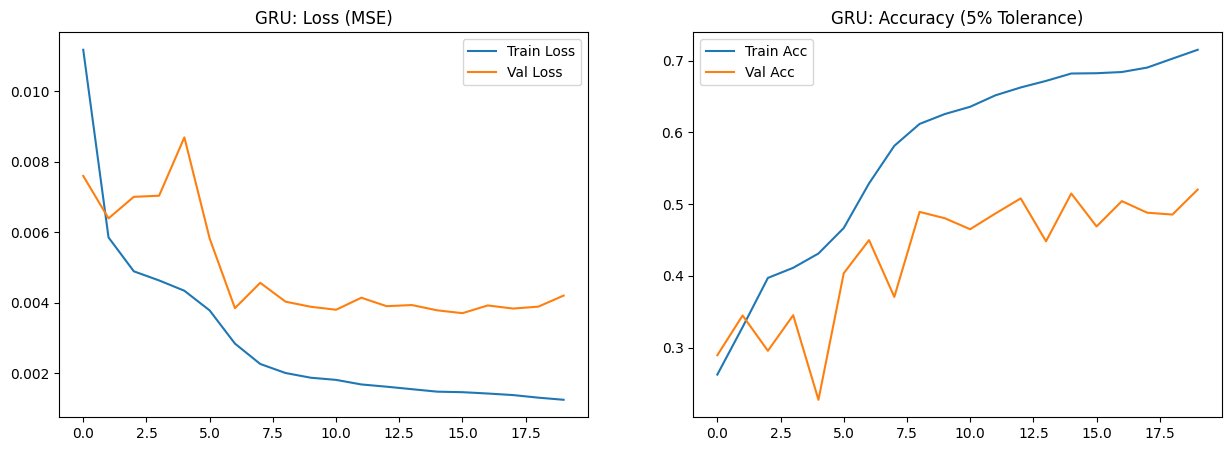

In [72]:
epochs = 20
gru_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    model_gru.train()
    train_loss, train_acc = 0, 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_gru(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_acc += calculate_accuracy(batch_y, outputs).item()
    
    model_gru.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model_gru(batch_X)
            v_loss = criterion(outputs, batch_y)
            val_loss += v_loss.item()
            val_acc += calculate_accuracy(batch_y, outputs).item()
    
    gru_history['train_loss'].append(train_loss / len(train_loader))
    gru_history['val_loss'].append(val_loss / len(test_loader))
    gru_history['train_acc'].append(train_acc / len(train_loader))
    gru_history['val_acc'].append(val_acc / len(test_loader))
    
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Loss (T/V): {gru_history['train_loss'][-1]:.5f} / {gru_history['val_loss'][-1]:.5f} | "
          f"Acc (T/V): {gru_history['train_acc'][-1]:.2%} / {gru_history['val_acc'][-1]:.2%}")

# --- Визуализация ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(gru_history['train_loss'], label='Train Loss')
ax1.plot(gru_history['val_loss'], label='Val Loss')
ax1.set_title('GRU: Loss (MSE)')
ax1.legend()

ax2.plot(gru_history['train_acc'], label='Train Acc')
ax2.plot(gru_history['val_acc'], label='Val Acc')
ax2.set_title('GRU: Accuracy (5% Tolerance)')
ax2.legend()
plt.show()

# Оценить точность модели с помощью метрик MSE, MAE и R²

In [42]:
def evaluate_model_performance(y_true, y_pred, model_name="Model"):
    """
    Расчет и вывод метрик MSE, MAE, R2 и MAPE.
    """
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE (средняя абсолютная ошибка в процентах)
    # Добавляем небольшое число в знаменатель, чтобы избежать деления на ноль
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

    print(f"--- {model_name} Evaluation ---")
    print(f"MSE  (Mean Squared Error):      {mse:.4f}")
    print(f"MAE  (Mean Absolute Error):     {mae:.4f}")
    print(f"R²   (Coefficient of Det.):     {r2:.4f}")
    print(f"MAPE (Mean Abs. Percent Error): {mape:.2f}%")
    
    return {"mse": mse, "mae": mae, "r2": r2, "mape": mape}

In [43]:
# 1. Переводим модель в режим оценки
model.eval()

# 2. Получаем предсказания на тестовой выборке
with torch.no_grad():
    y_pred_tensor = model(X_test_t)
    # Переводим в numpy
    predictions = y_pred_tensor.numpy()

# 3. ОБРАТНОЕ МАСШТАБИРОВАНИЕ (Inverse Transform)
# Нам нужно превратить [0, 1] обратно в реальные значения нагрузки.
# Поскольку скейлер обучался на всех признаках (например, 10 колонок), 
# нам нужно создать временный массив такой же размерности.

tmp_pred = np.zeros((len(predictions), scaled_data.shape[1]))
tmp_true = np.zeros((len(y_test), scaled_data.shape[1]))

# Подставляем наши предсказания и реальные ответы в колонку, где была нагрузка (обычно индекс 0)
tmp_pred[:, 0] = predictions.flatten()
tmp_true[:, 0] = y_test.flatten()

# Инвертируем масштаб
final_pred = scaler.inverse_transform(tmp_pred)[:, 0]
final_true = scaler.inverse_transform(tmp_true)[:, 0]

# 4. ВЫЗОВ ФУНКЦИИ ОЦЕНКИ
results = evaluate_model_performance(final_true, final_pred, model_name="Simple RNN")

--- Simple RNN Evaluation ---
MSE  (Mean Squared Error):      18652.1171
MAE  (Mean Absolute Error):     94.0129
R²   (Coefficient of Det.):     0.4611
MAPE (Mean Abs. Percent Error): 8.08%


In [62]:
model_lstm.eval()
with torch.no_grad():
    lstm_preds = model_lstm(X_test_t).numpy()

# Инвертируем масштаб
tmp_pred = np.zeros((len(lstm_preds), scaled_data.shape[1]))
tmp_true = np.zeros((len(y_test), scaled_data.shape[1]))
tmp_pred[:, 0] = lstm_preds.flatten()
tmp_true[:, 0] = y_test.flatten()

final_pred_lstm = scaler.inverse_transform(tmp_pred)[:, 0]
final_true_lstm = scaler.inverse_transform(tmp_true)[:, 0]

# Твоя функция оценки
metrics_lstm = evaluate_model_performance(final_true_lstm, final_pred_lstm, model_name="LSTM")

--- LSTM Evaluation ---
MSE  (Mean Squared Error):      15324.1556
MAE  (Mean Absolute Error):     84.1670
R²   (Coefficient of Det.):     0.5573
MAPE (Mean Abs. Percent Error): 7.20%


In [73]:
model_gru.eval()
with torch.no_grad():
    gru_preds = model_gru(X_test_t).cpu().numpy()

# Инвертируем нормализацию (обратное масштабирование)
tmp_pred = np.zeros((len(gru_preds), scaled_data.shape[1]))
tmp_true = np.zeros((len(y_test), scaled_data.shape[1]))
tmp_pred[:, 0] = gru_preds.flatten()
tmp_true[:, 0] = y_test.flatten()

final_pred_gru = scaler.inverse_transform(tmp_pred)[:, 0]
final_true_gru = scaler.inverse_transform(tmp_true)[:, 0]

# Вызов твоей функции
metrics_gru = evaluate_model_performance(final_true_gru, final_pred_gru, model_name="GRU")

--- GRU Evaluation ---
MSE  (Mean Squared Error):      11698.9350
MAE  (Mean Absolute Error):     77.4518
R²   (Coefficient of Det.):     0.6620
MAPE (Mean Abs. Percent Error): 6.57%
